L. Parker and S. M. Christensen, *MathTensor: A System for Doing Tensor Analysis by Computer* (Addison-Wesley, 1994)

In [1]:
<< mTensor`

# Chapter 8. Nonlinear Elasticity in Engineering Mechanics

## 8.1 Finite Deformation of a Body

## 8.2 Simple Shear Deformation of a Solid

### 8.2.1 Finding the Metric Tensors

In [2]:
coords = {x, y, z};
trans = {x + K y, y, z};

In [4]:
Tdefine[{ga, g}, "ba"]

In [5]:
SetComponents[g[la, lb], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}]

In [6]:
Ttransform[ga, g[la, lb], coords, trans]

1        K        0

              2
K        1 + K    0


0        0        1
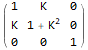

In [7]:
Table[ga[-i, -j], {i, 3}, {j, 3}] // MatrixForm

### 8.2.2 Finding the Invariants $I_1$, $I_2$, and $I_3$

In [8]:
gaLowerMat = Table[ga[-i, -j], {i, 3}, {j, 3}]

2
{{1, K, 0}, {K, 1 + K , 0}, {0, 0, 1}}

In [9]:
gaUpperMat = Inverse[gaLowerMat]

2
{{1 + K , -K, 0}, {-K, 1, 0}, {0, 0, 1}}

In [10]:
ga[a_, b_] /; PositiveIntegerQ[a] && PositiveIntegerQ[b] := 
 gaUpperMat[[a, b]]

In [11]:
detga = Det[gaLowerMat]

1

In [12]:
I3 = 1

1

In [13]:
SetComponents[g[ua, ub], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}]

In [14]:
SetDimension[3]

In [15]:
I1 = SumDum[g[ua, ub] ga[la, lb]]

2
3 + K

In [16]:
I2 = SumDum[ga[ua, ub] g[la, lb]]

2
3 + K

### 8.2.3 Finding the Stress Tensor

In [17]:
Tdefine[B, "ba"]

In [18]:
B[a_, b_] /; PositiveIntegerQ[a] && PositiveIntegerQ[b] := 
 I1 g[a, b] - SumDum[g[a, ua] g[b, ub] ga[la, lb]]

2
2 + K    -K       0


-K       2        0

                       2
0        0        2 + K
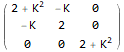

In [19]:
Table[B[i, j], {i, 3}, {j, 3}] // MatrixForm

In [20]:
Tdefine[t, "ba"]

In [21]:
t[a_, b_] /; 
  PositiveIntegerQ[a] && 
   PositiveIntegerQ[b] := \[CapitalPhi] g[a, b] + \[CapitalPsi] B[a, 
    b] + p ga[a, b]

In [22]:
t[1, 1]

2                2
(1 + K ) p + Φ + (2 + K ) Ψ

2                2
(1 + K ) p + Φ + (2 + K ) Ψ   -(K p) - K Ψ                  0


-(K p) - K Ψ                  p + Φ + 2 Ψ                   0

                                                                          2
0                             0                             p + Φ + (2 + K ) Ψ
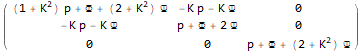

In [23]:
Table[t[i, j], {i, 3}, {j, 3}] // MatrixForm

### 8.2.4 Finding the Surface Forces

In [24]:
pRule := p -> -\[CapitalPhi] - (1 + K - 2) \[CapitalPsi]

2                2
(1 + K ) p + Φ + (2 + K ) Ψ
---------------------------
               2
          1 + K
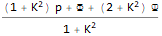

In [25]:
Pnorm = ga[1, 1]^-1 t[1, 1]

2            2
Φ + (2 + K ) Ψ - (1 + K ) (Φ + (-1 + K) Ψ)
------------------------------------------
                       2
                  1 + K
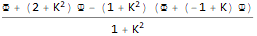

In [26]:
% /. pRule // Simplify

K (Φ + Ψ)
---------
      2
 1 + K
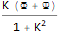

In [27]:
Ptan = SumDum[ga[1, 1]^(-1/2) t[1, ub] ga[lb, -2] ga[-2, -2]^(-1/2)] //
   Simplify

## 8.3 Cylinder Twisted about its Axis

### 8.3.1 Metrics

In [28]:
coords = {r, \[Theta], z};
trans = {r Cos[\[Theta] - k z], r Sin[\[Theta] - k z], z};

In [30]:
Tdefine[{gb, g}, "ba"]

In [31]:
SetComponents[g[la, lb], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}]

In [32]:
Ttransform[gb, g[la, lb], coords, trans]

In [33]:
gbLowerMat = Table[gb[-i, -j], {i, 3}, {j, 3}];

1           0           0

             2               2
0           r           -(k r )

                 2           2  2
0           -(k r )     1 + k  r
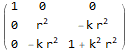

In [34]:
gbLowerMat // MatrixForm

2  2
                1 + k  r
{{1, 0, 0}, {0, ---------, k}, {0, k, 1}}
                    2
                   r
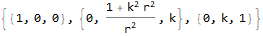

In [35]:
gbUpperMat = Inverse[gbLowerMat]

In [36]:
gb[a_, b_] /; PositiveIntegerQ[a] && PositiveIntegerQ[b] := 
 gbUpperMat[[a, b]]

In [37]:
gLowerMat = {{1, 0, 0}, {0, r^2, 0}, {0, 0, 1}};

In [38]:
SetComponents[Metricg[la, lb], gLowerMat]

-2
{{1, 0, 0}, {0, r  , 0}, {0, 0, 1}}
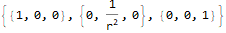

In [39]:
gUpperMat = Inverse[gLowerMat]

In [40]:
SetComponents[Metricg[ua, ub], gUpperMat]

### 8.3.2 Invariants $I_1$, $I_2$, and $I_3$

In [41]:
detgb = Det[gbLowerMat]

2
r

In [42]:
detMetricg = Det[gLowerMat]

2
r

In [43]:
I3 = detMetricg/detgb

1

In [44]:
SetDimension[3]

In [45]:
I1 = SumDum[gb[ua, ub] Metricg[la, lb]]

2  2
3 + k  r

In [46]:
I2 = I3*SumDum[Metricg[ua, ub] gb[la, lb]]

2  2
3 + k  r

### 8.3.3 Stress Tensor

In [47]:
Tdefine[B, "ba"]

In [48]:
B[a_, b_] /; PositiveIntegerQ[a] && PositiveIntegerQ[b] := 
 I1 gb[a, b] - SumDum[gb[a, ua] gb[b, ub] Metricg[la, lb]] // Simplify

2  2
2 + k  r    0           0

             2   2
            k  + --
                  2
0                r      k




0           k           2
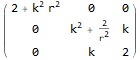

In [49]:
Table[B[i, j], {i, 3}, {j, 3}] // MatrixForm

In [50]:
Tdefine[t, "ba"]

In [51]:
t[a_, b_] /; 
  PositiveIntegerQ[a] && 
   PositiveIntegerQ[
    b] := \[CapitalPhi] gb[a, b] + \[CapitalPsi] B[a, b] + 
   p Metricg[a, b] // Simplify

2  2
p + Φ + (2 + k  r ) Ψ             0
 




>    0

                                           2  2            2  2
                                  p + Φ + k  r  Φ + 2 Ψ + k  r  Ψ
                                  -------------------------------
                                                 2
0                                               r
 




>    k (Φ + Ψ)





0                                 k (Φ + Ψ)
 




>    p + Φ + 2 Ψ
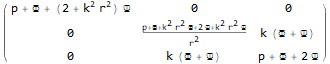

In [52]:
Table[t[i, j], {i, 3}, {j, 3}] // MatrixForm

### 8.3.4 Equilibrium Equations

In [53]:
coSys = {r, \[Theta], z};
metric = {{1, 0, 0}, {0, r^2, 0}, {0, 0, 1}};

In [55]:
InitCTensor[coSys, metric, RicciCD -> True]

1     0     0

       -2
0     r     0


0     0     1
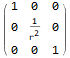

In [56]:
Table[Metricg[i, j], {i, 3}, {j, 3}] // MatrixForm

2  2
p + Φ + (2 + k  r ) Ψ             0
 




>    0

                                           2  2            2  2
                                  p + Φ + k  r  Φ + 2 Ψ + k  r  Ψ
                                  -------------------------------
                                                 2
0                                               r
 




>    k (Φ + Ψ)





0                                 k (Φ + Ψ)
 




>    p + Φ + 2 Ψ
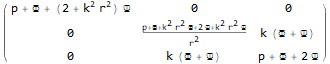

In [57]:
tmat = Table[t[i, j], {i, 3}, {j, 3}]; tmat // MatrixForm

In [58]:
SetComponents[t[ua, ub], 
 tmat /. {p -> 
    p[r, \[Theta], z], \[CapitalPhi] -> \[CapitalPhi][
     r], \[CapitalPsi] -> \[CapitalPsi][r]}]

In [59]:
CD[lb, t[ua, ub]]

CD[lb, t[ua, ub]]

In [60]:
% // CDtoGamma

BD[lb, t[ua, ub]] + GammaCD[lb, lc, ub] t[ua, uc] + GammaCD[lb, lc, ua] t[uc, ub]

t[ua, 1]
BD[-3, t[ua, 3]] + BD[-2, t[ua, 2]] + BD[-1, t[ua, 1]] + -------- + 
                                                            r
 
>   k GammaCD[-3, -2, ua] (Φ[r] + Ψ[r]) + k GammaCD[-2, -3, ua] (Φ[r] + Ψ[r]) + 
 
>   GammaCD[-3, -3, ua] (p[r, θ, z] + Φ[r] + 2 Ψ[r]) + 
 
                                              2  2                  2  2
    GammaCD[-2, -2, ua] (p[r, θ, z] + Φ[r] + k  r  Φ[r] + 2 Ψ[r] + k  r  Ψ[r])
>   -------------------------------------------------------------------------- + 
                                         2
                                        r
 
                                                   2  2
>   GammaCD[-1, -1, ua] (p[r, θ, z] + Φ[r] + (2 + k  r ) Ψ[r])
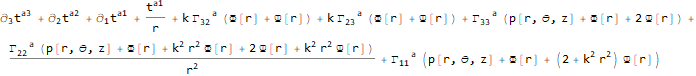

In [61]:
divStress[ua_] = SumDum[%]

In [62]:
rDiv = divStress[1] // Simplify

2              2                             2  2          (1,0,0)
-(k  r Φ[r]) + 2 k  r Ψ[r] + Φ'[r] + 2 Ψ'[r] + k  r  Ψ'[r] + p       [r, θ, z]

(0,1,0)
p       [r, θ, z]
-----------------
        2
       r
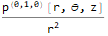

In [63]:
\[Theta]Div = divStress[2] // Simplify

In [64]:
zDiv = divStress[3] // Simplify

(0,0,1)
p       [r, θ, z]

In [65]:
pDependRule = {Derivative[1, 0, 0][p][r, \[Theta], z] -> p'[r]}

(1,0,0)
{p       [r, θ, z] -> p'[r]}

In [66]:
rDiv /. pDependRule

2              2                                     2  2
-(k  r Φ[r]) + 2 k  r Ψ[r] + p'[r] + Φ'[r] + 2 Ψ'[r] + k  r  Ψ'[r]

나머지 생략